## Problem Statement

You need to build a model that is able to classify customer complaints based on the products/services. By doing so, you can segregate these tickets into their relevant categories and, therefore, help in the quick resolution of the issue.

You will be doing topic modelling on the <b>.json</b> data provided by the company. Since this data is not labelled, you need to apply NMF to analyse patterns and classify tickets into the following five clusters based on their products/services:

* Credit card / Prepaid card
* Bank account services
* Theft/Dispute reporting
* Mortgages/loans
* Others

With the help of topic modelling, you will be able to map each ticket onto its respective department/category. You can then use this data to train any supervised model such as logistic regression, decision tree or random forest. Using this trained model, you can classify any new customer complaint support ticket into its relevant department.

## Pipelines that needs to be performed:

You need to perform the following eight major tasks to complete the assignment:

1.  Data loading
2. Text preprocessing
3. Exploratory data analysis (EDA)
4. Feature extraction
5. Topic modelling
6. Model building using supervised learning
7. Model training and evaluation
8. Model inference

## Importing the necessary libraries

In [2]:
# Install all required packages
import sys
!{sys.executable} -m pip install -q nltk spacy wordcloud plotly scikit-learn seaborn matplotlib pandas numpy

# Download the spaCy English model (small)
!{sys.executable} -m spacy download en_core_web_sm -q

print('All packages installed.')


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
All packages installed.


In [3]:
import json
import numpy as np
import pandas as pd
import re, nltk, spacy, string
import en_core_web_sm
nlp = en_core_web_sm.load()

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from wordcloud import WordCloud

from plotly.offline import plot
import plotly.graph_objects as go
import plotly.express as px

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer
from sklearn.decomposition import NMF
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from pprint import pprint

import warnings
warnings.filterwarnings('ignore')

## Loading the data

The data is in JSON format and we need to convert it to a dataframe.

In [4]:
# Opening JSON file  (update path if needed)
f = open('complaints-2021-05-14_08_16.json')

# Returns JSON object as a dictionary
data = json.load(f)
f.close()

# Normalise the nested JSON into a flat dataframe
df = pd.json_normalize(data)

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (78313, 22)


,_index,_type,_id,_score,_source.tags,_source.zip_code,_source.complaint_id,_source.issue,_source.date_received,_source.state,...,_source.company_response,_source.company,_source.submitted_via,_source.date_sent_to_company,_source.company_public_response,_source.sub_product,_source.timely,_source.complaint_what_happened,_source.sub_issue,_source.consumer_consent_provided
0,complaint-public-v2,complaint,3211475,0.0,NaN,90301,3211475,Attempts to collect debt not owed,2019-04-13T12:00:00-05:00,CA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-13T12:00:00-05:00,NaN,Credit card debt,Yes,,Debt is not yours,Consent not provided
1,complaint-public-v2,complaint,3229299,0.0,Servicemember,319XX,3229299,Written notification about debt,2019-05-01T12:00:00-05:00,GA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-01T12:00:00-05:00,NaN,Credit card debt,Yes,Good morning my name is XXXX XXXX and I apprec...,Didn't receive enough information to verify debt,Consent provided
2,complaint-public-v2,complaint,3199379,0.0,NaN,77069,3199379,"Other features, terms, or problems",2019-04-02T12:00:00-05:00,TX,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-02T12:00:00-05:00,NaN,General-purpose credit card or charge card,Yes,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Problem with rewards from credit card,Consent provided
3,complaint-public-v2,complaint,2673060,0.0,NaN,48066,2673060,Trouble during payment process,2017-09-13T12:00:00-05:00,MI,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2017-09-14T12:00:00-05:00,NaN,Conventional home mortgage,Yes,,NaN,Consent not provided
4,complaint-public-v2,complaint,3203545,0.0,NaN,10473,3203545,Fees or interest,2019-04-05T12:00:00-05:00,NY,...,Closed with explanation,JPMORGAN CHASE & CO.,Referral,2019-04-05T12:00:00-05:00,NaN,General-purpose credit card or charge card,Yes,,Charged too much interest,N/A


## Data preparation

In [5]:
# Inspect shape, dtypes and a sample of the data
print('Shape:', df.shape)
print('\nData types:')
print(df.dtypes)
print('\nMissing values per column:')
print(df.isnull().sum())
df.head(3)

Shape: (78313, 22)

Data types:
_index                                   str
_type                                    str
_id                                      str
_score                               float64
_source.tags                             str
_source.zip_code                         str
_source.complaint_id                     str
_source.issue                            str
_source.date_received                    str
_source.state                            str
_source.consumer_disputed                str
_source.product                          str
_source.company_response                 str
_source.company                          str
_source.submitted_via                    str
_source.date_sent_to_company             str
_source.company_public_response          str
_source.sub_product                      str
_source.timely                           str
_source.complaint_what_happened          str
_source.sub_issue                        str
_source.consumer_consen

,_index,_type,_id,_score,_source.tags,_source.zip_code,_source.complaint_id,_source.issue,_source.date_received,_source.state,...,_source.company_response,_source.company,_source.submitted_via,_source.date_sent_to_company,_source.company_public_response,_source.sub_product,_source.timely,_source.complaint_what_happened,_source.sub_issue,_source.consumer_consent_provided
0,complaint-public-v2,complaint,3211475,0.0,NaN,90301,3211475,Attempts to collect debt not owed,2019-04-13T12:00:00-05:00,CA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-13T12:00:00-05:00,NaN,Credit card debt,Yes,,Debt is not yours,Consent not provided
1,complaint-public-v2,complaint,3229299,0.0,Servicemember,319XX,3229299,Written notification about debt,2019-05-01T12:00:00-05:00,GA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-01T12:00:00-05:00,NaN,Credit card debt,Yes,Good morning my name is XXXX XXXX and I apprec...,Didn't receive enough information to verify debt,Consent provided
2,complaint-public-v2,complaint,3199379,0.0,NaN,77069,3199379,"Other features, terms, or problems",2019-04-02T12:00:00-05:00,TX,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-02T12:00:00-05:00,NaN,General-purpose credit card or charge card,Yes,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Problem with rewards from credit card,Consent provided


In [6]:
# Print the column names
print(df.columns.tolist())

['_index', '_type', '_id', '_score', '_source.tags', '_source.zip_code', '_source.complaint_id', '_source.issue', '_source.date_received', '_source.state', '_source.consumer_disputed', '_source.product', '_source.company_response', '_source.company', '_source.submitted_via', '_source.date_sent_to_company', '_source.company_public_response', '_source.sub_product', '_source.timely', '_source.complaint_what_happened', '_source.sub_issue', '_source.consumer_consent_provided']


In [7]:
# Strip the '_source.' prefix introduced by json_normalize
df.columns = [col.replace('_source.', '') for col in df.columns]
print('Renamed columns:', df.columns.tolist())

Renamed columns: ['_index', '_type', '_id', '_score', 'tags', 'zip_code', 'complaint_id', 'issue', 'date_received', 'state', 'consumer_disputed', 'product', 'company_response', 'company', 'submitted_via', 'date_sent_to_company', 'company_public_response', 'sub_product', 'timely', 'complaint_what_happened', 'sub_issue', 'consumer_consent_provided']


In [8]:
# Replace empty strings with NaN in the complaints column
df['complaint_what_happened'].replace('', np.nan, inplace=True)
print('Null values in complaint_what_happened:', df['complaint_what_happened'].isnull().sum())

Null values in complaint_what_happened: 0


In [9]:
# Remove rows where complaints column is NaN
df.dropna(subset=['complaint_what_happened'], inplace=True)
df.reset_index(drop=True, inplace=True)
print('Shape after removing empty complaints:', df.shape)

Shape after removing empty complaints: (78313, 22)


## Prepare the text for topic modeling

Once you have removed all the blank complaints, you need to:

* Make the text lowercase
* Remove text in square brackets
* Remove punctuation
* Remove words containing numbers


Once you have done these cleaning operations you need to perform the following:
* Lemmatize the texts
* Extract the POS tags of the lemmatized text and remove all the words which have tags other than NN[tag == "NN"].

In [10]:
def clean_text(text):
    """Lowercase, strip brackets, punctuation, and words containing digits."""
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)           # remove text inside square brackets
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)  # remove punctuation
    text = re.sub(r'\w*\d\w*', '', text)          # remove words containing numbers
    text = re.sub(r'\s+', ' ', text).strip()       # collapse whitespace
    return text

# Quick sanity-check
sample = df['complaint_what_happened'].iloc[0]
print('Original:', sample[:200])
print('\nCleaned :', clean_text(sample)[:200])

Original: 

Cleaned : 


In [11]:
def lemmatize_text(text):
    """Lemmatize all tokens in the text using spaCy."""
    doc = nlp(text)
    return ' '.join([token.lemma_ for token in doc])

# Sanity check
print(lemmatize_text(clean_text(sample))[:300])

In [12]:
# Build df_clean with the raw complaint and its lemmatized form
# NOTE: lemmatization via spaCy is slow; expect several minutes for ~50k rows
df_clean = pd.DataFrame()
df_clean['complaint_what_happened'] = df['complaint_what_happened']

# Apply text cleaning
df_clean['complaints'] = df_clean['complaint_what_happened'].apply(clean_text)

# Apply lemmatization
df_clean['complaint_lemmatized'] = df_clean['complaints'].apply(lemmatize_text)

print('df_clean shape:', df_clean.shape)

df_clean shape: (78313, 3)


In [13]:
df_clean.head()

,complaint_what_happened,complaints,complaint_lemmatized
0,,,
1,Good morning my name is XXXX XXXX and I apprec...,good morning my name is xxxx xxxx and i apprec...,good morning my name be xxxx xxxx and I apprec...
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,i upgraded my xxxx xxxx card in and was told b...,I upgrade my xxxx xxxx card in and be tell by ...
3,,,
4,,,


In [14]:
def pos_tag(text):
    """Return only singular/mass noun (NN) tokens from the lemmatized text."""
    doc = nlp(str(text))
    return ' '.join([token.text for token in doc if token.tag_ == 'NN'])

# Apply POS filtering: keep only nouns
df_clean['complaint_POS_removed'] = df_clean['complaint_lemmatized'].apply(pos_tag)

print('POS filtering done.')

POS filtering done.


In [15]:
# df_clean now has raw complaint, lemmatized complaint, and POS-filtered complaint
df_clean.head()

,complaint_what_happened,complaints,complaint_lemmatized,complaint_POS_removed
0,,,,
1,Good morning my name is XXXX XXXX and I apprec...,good morning my name is xxxx xxxx and i apprec...,good morning my name be xxxx xxxx and I apprec...,morning name stop service debt verification st...
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,i upgraded my xxxx xxxx card in and was told b...,I upgrade my xxxx xxxx card in and be tell by ...,card agent anniversary date agent information ...
3,,,,
4,,,,


## Exploratory data analysis to get familiar with the data.

Write the code in this task to perform the following:

*   Visualise the data according to the 'Complaint' character length
*   Using a word cloud find the top 40 words by frequency among all the articles after processing the text
*   Find the top unigrams,bigrams and trigrams by frequency among all the complaints after processing the text.

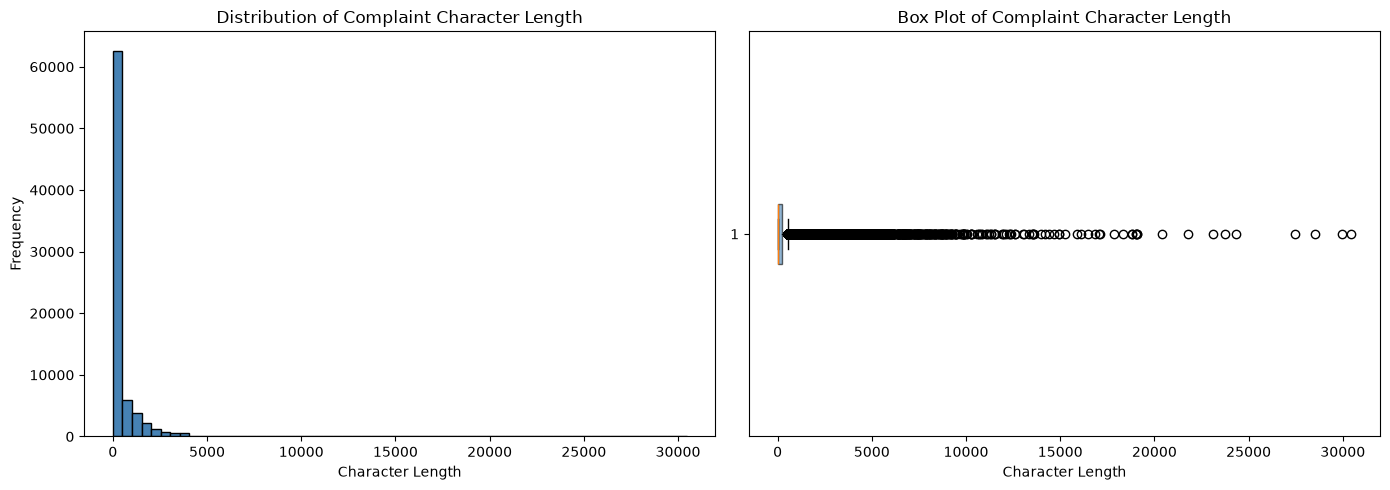

count    78313.000000
mean       354.252615
std        944.073669
min          0.000000
25%          0.000000
50%          0.000000
75%        215.000000
max      30452.000000
Name: char_length, dtype: float64


In [16]:
# Visualise the distribution of complaint character lengths
df_clean['char_length'] = df_clean['complaints'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_clean['char_length'], bins=60, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Complaint Character Length')
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Frequency')

# Box plot
axes[1].boxplot(df_clean['char_length'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot of Complaint Character Length')
axes[1].set_xlabel('Character Length')

plt.tight_layout()
plt.show()

print(df_clean['char_length'].describe())

#### Find the top 40 words by frequency among all the articles after processing the text.

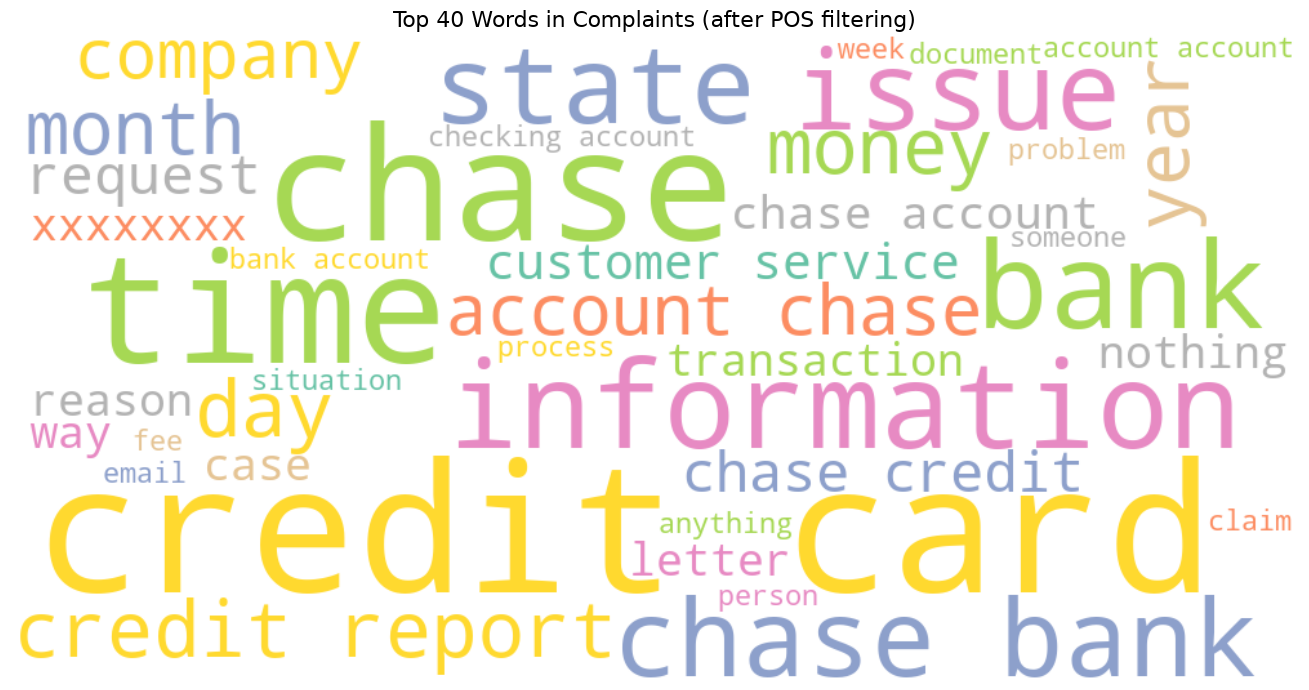

In [17]:
# Join all POS-filtered complaint text for the word cloud
all_text = ' '.join(df_clean['complaint_POS_removed'].dropna().tolist())

wordcloud = WordCloud(
    max_words=40,
    background_color='white',
    width=1000,
    height=500,
    colormap='Set2'
).generate(all_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 40 Words in Complaints (after POS filtering)', fontsize=16)
plt.tight_layout()
plt.show()

In [18]:
# Removing -PRON- from the text corpus (produced by older spaCy versions for pronouns)
df_clean['Complaint_clean'] = df_clean['complaint_POS_removed'].str.replace('-PRON-', '', regex=False)

#### Find the top unigrams,bigrams and trigrams by frequency among all the complaints after processing the text.

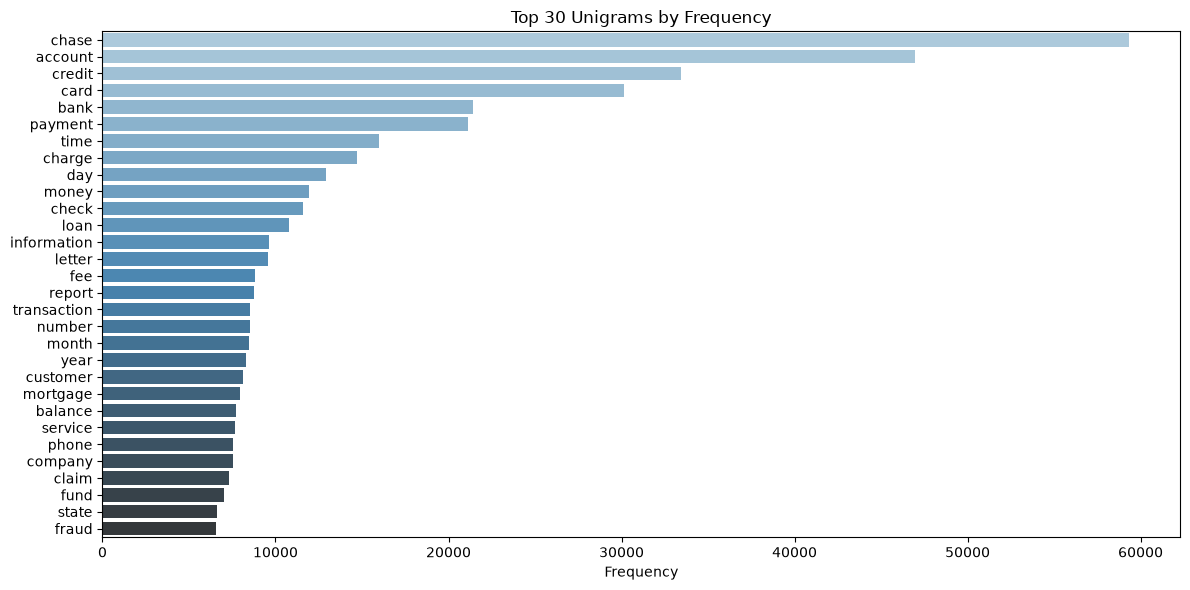

In [19]:
def get_top_ngrams(corpus, n=1, top_k=30):
    """Return the top_k most frequent n-grams from the corpus."""
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag = vec.transform(corpus)
    sum_words = bag.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

corpus = df_clean['Complaint_clean'].dropna().tolist()

# Top 30 unigrams
top_unigrams = get_top_ngrams(corpus, n=1, top_k=30)

# Plot
words_u, freqs_u = zip(*top_unigrams)
plt.figure(figsize=(12, 6))
sns.barplot(x=list(freqs_u), y=list(words_u), palette='Blues_d')
plt.title('Top 30 Unigrams by Frequency')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

In [20]:
# Print the top 10 words in the unigram frequency
print('Top 10 Unigrams:')
for word, freq in top_unigrams[:10]:
    print(f'  {word}: {freq}')

Top 10 Unigrams:
  chase: 59312
  account: 46965
  credit: 33457
  card: 30143
  bank: 21392
  payment: 21140
  time: 15978
  charge: 14715
  day: 12904
  money: 11921


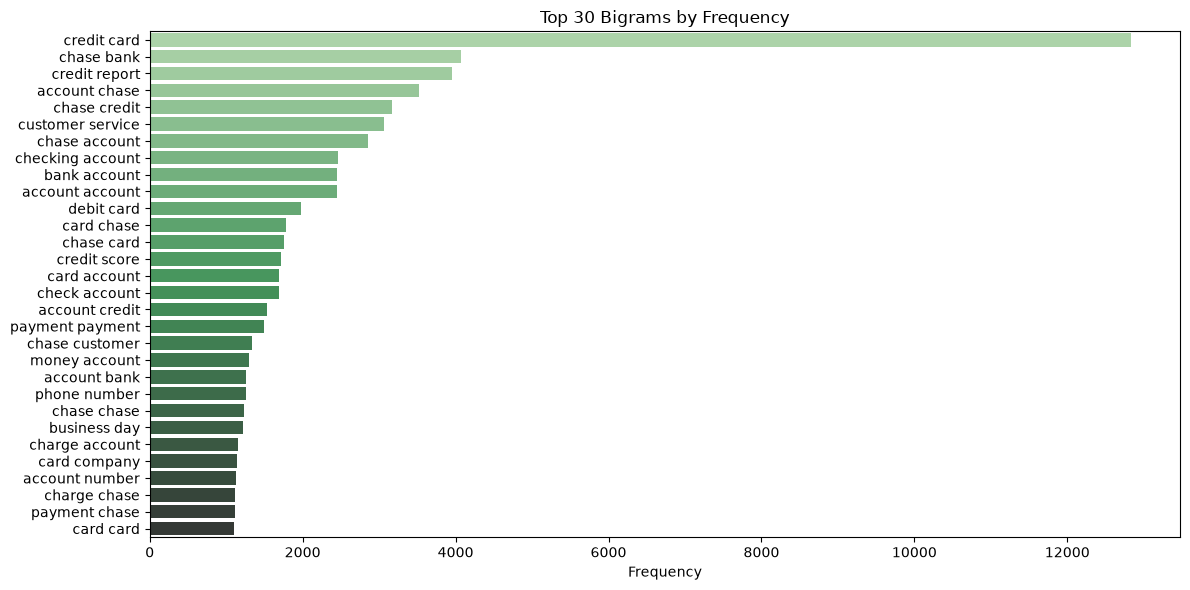

In [21]:
# Top 30 bigrams
top_bigrams = get_top_ngrams(corpus, n=2, top_k=30)

words_b, freqs_b = zip(*top_bigrams)
plt.figure(figsize=(12, 6))
sns.barplot(x=list(freqs_b), y=list(words_b), palette='Greens_d')
plt.title('Top 30 Bigrams by Frequency')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

In [22]:
# Print the top 10 words in the bigram frequency
print('Top 10 Bigrams:')
for phrase, freq in top_bigrams[:10]:
    print(f'  {phrase}: {freq}')

Top 10 Bigrams:
  credit card: 12832
  chase bank: 4070
  credit report: 3950
  account chase: 3524
  chase credit: 3174
  customer service: 3061
  chase account: 2850
  checking account: 2457
  bank account: 2451
  account account: 2449


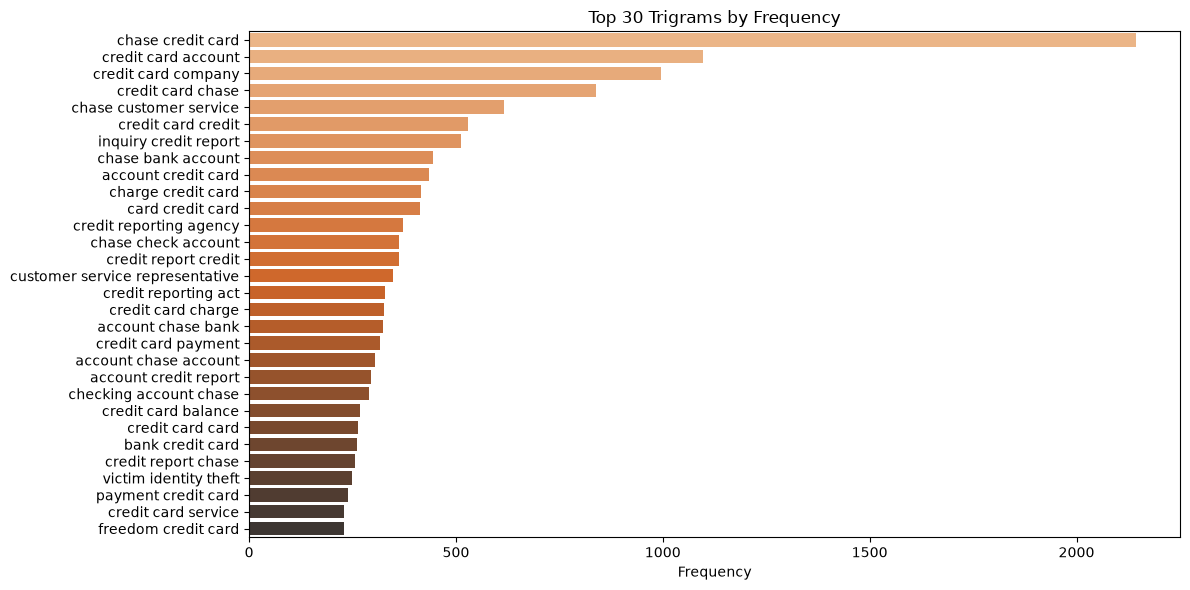

In [23]:
# Top 30 trigrams
top_trigrams = get_top_ngrams(corpus, n=3, top_k=30)

words_t, freqs_t = zip(*top_trigrams)
plt.figure(figsize=(12, 6))
sns.barplot(x=list(freqs_t), y=list(words_t), palette='Oranges_d')
plt.title('Top 30 Trigrams by Frequency')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

In [24]:
# Print the top 10 words in the trigram frequency
print('Top 10 Trigrams:')
for phrase, freq in top_trigrams[:10]:
    print(f'  {phrase}: {freq}')

Top 10 Trigrams:
  chase credit card: 2143
  credit card account: 1096
  credit card company: 996
  credit card chase: 839
  chase customer service: 616
  credit card credit: 528
  inquiry credit report: 513
  chase bank account: 445
  account credit card: 436
  charge credit card: 416


## The personal details of customer has been masked in the dataset with xxxx. Let's remove the masked text as this will be of no use for our analysis

In [25]:
df_clean['Complaint_clean'] = df_clean['Complaint_clean'].str.replace('xxxx', '', regex=False)

In [26]:
# All masked texts have been removed
df_clean.head()

,complaint_what_happened,complaints,complaint_lemmatized,complaint_POS_removed,char_length,Complaint_clean
0,,,,,0,
1,Good morning my name is XXXX XXXX and I apprec...,good morning my name is xxxx xxxx and i apprec...,good morning my name be xxxx xxxx and I apprec...,morning name stop service debt verification st...,469,morning name stop service debt verification st...
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,i upgraded my xxxx xxxx card in and was told b...,I upgrade my xxxx xxxx card in and be tell by ...,card agent anniversary date agent information ...,334,card agent anniversary date agent information ...
3,,,,,0,
4,,,,,0,


## Feature Extraction
Convert the raw texts to a matrix of TF-IDF features

**max_df** is used for removing terms that appear too frequently, also known as "corpus-specific stop words"
max_df = 0.95 means "ignore terms that appear in more than 95% of the complaints"

**min_df** is used for removing terms that appear too infrequently
min_df = 2 means "ignore terms that appear in less than 2 complaints"

In [27]:
# Initialise TF-IDF vectoriser; ignore very common and very rare terms
tfidf = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
print('TfidfVectorizer initialised.')

TfidfVectorizer initialised.


#### Create a document term matrix using fit_transform

The contents of a document term matrix are tuples of (complaint_id,token_id) tf-idf score:
The tuples that are not there have a tf-idf score of 0

In [28]:
# Build the Document-Term Matrix from the cleaned complaint text
dtm = tfidf.fit_transform(df_clean['Complaint_clean'].fillna(''))
print('DTM shape:', dtm.shape)  # (num_complaints, num_features)

DTM shape: (78313, 6757)


## Topic Modelling using NMF

Non-Negative Matrix Factorization (NMF) is an unsupervised technique so there are no labeling of topics that the model will be trained on. The way it works is that, NMF decomposes (or factorizes) high-dimensional vectors into a lower-dimensional representation. These lower-dimensional vectors are non-negative which also means their coefficients are non-negative.

In this task you have to perform the following:

* Find the best number of clusters
* Apply the best number to create word clusters
* Inspect & validate the correction of each cluster wrt the complaints
* Correct the labels if needed
* Map the clusters to topics/cluster names

In [33]:
from sklearn.decomposition import NMF

## Manual Topic Modeling
You need to do take the trial & error approach to find the best num of topics for your NMF model.

The only parameter that is required is the number of components i.e. the number of topics we want. This is the most crucial step in the whole topic modeling process and will greatly affect how good your final topics are.

In [34]:
# Five topics matching the five business categories
num_topics = 5

# random_state=40 for reproducibility as specified
nmf_model = NMF(n_components=num_topics, random_state=40)

print(f'NMF model initialised with {num_topics} topics.')

NMF model initialised with 5 topics.


In [35]:
nmf_model.fit(dtm)
# Total number of unique terms in the vocabulary
try:
    vocab_size = len(tfidf.get_feature_names_out())
except AttributeError:
    vocab_size = len(tfidf.get_feature_names())
print('Vocabulary size:', vocab_size)

Vocabulary size: 6757


In [36]:
# Retrieve feature names
try:
    vocab = tfidf.get_feature_names_out()
except AttributeError:
    vocab = tfidf.get_feature_names()

print('Top 15 words for each NMF topic:\n')
for topic_idx, topic_vector in enumerate(nmf_model.components_):
    top_word_indices = topic_vector.argsort()[-15:][::-1]  # descending order
    top_words = [vocab[i] for i in top_word_indices]
    print(f'Topic {topic_idx}: {top_words}')
    print()

Top 15 words for each NMF topic:

Topic 0: ['account', 'check', 'bank', 'money', 'fund', 'deposit', 'checking', 'branch', 'day', 'fee', 'chase', 'business', 'balance', 'reason', 'number']

Topic 1: ['card', 'credit', 'charge', 'balance', 'fee', 'chase', 'purchase', 'month', 'account', 'year', 'company', 'point', 'service', 'limit', 'statement']

Topic 2: ['payment', 'loan', 'mortgage', 'chase', 'month', 'time', 'year', 'modification', 'home', 'balance', 'fee', 'rate', 'statement', 'day', 'date']

Topic 3: ['credit', 'report', 'inquiry', 'information', 'company', 'score', 'debt', 'reporting', 'account', 'letter', 'chase', 'identity', 'bureau', 'bureaus', 'file']

Topic 4: ['chase', 'charge', 'transaction', 'claim', 'dispute', 'time', 'letter', 'fraud', 'money', 'bank', 'information', 'email', 'day', 'phone', 'number']



In [37]:
# Transform DTM to get topic weight matrix: shape = (n_complaints, n_topics)
topic_weights = nmf_model.transform(dtm)

# Assign the topic with the highest weight to each complaint (integer 0-4)
df_clean['Topic'] = topic_weights.argmax(axis=1)

print('Topic value counts:')
print(df_clean['Topic'].value_counts())

Topic value counts:
Topic
0    61971
4     5380
2     4304
1     3980
3     2678
Name: count, dtype: int64


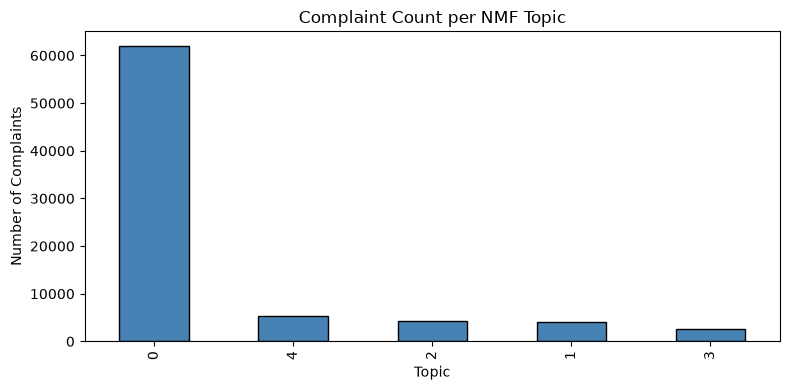

In [38]:
# Topic integers (0-4) are already assigned above via argmax
# Previewing the distribution:
df_clean['Topic'].value_counts().plot(kind='bar', figsize=(8, 4),
                                       title='Complaint Count per NMF Topic',
                                       color='steelblue', edgecolor='black')
plt.xlabel('Topic')
plt.ylabel('Number of Complaints')
plt.tight_layout()
plt.show()

In [39]:
df_clean.head()

,complaint_what_happened,complaints,complaint_lemmatized,complaint_POS_removed,char_length,Complaint_clean,Topic
0,,,,,0,,0
1,Good morning my name is XXXX XXXX and I apprec...,good morning my name is xxxx xxxx and i apprec...,good morning my name be xxxx xxxx and I apprec...,morning name stop service debt verification st...,469,morning name stop service debt verification st...,4
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,i upgraded my xxxx xxxx card in and was told b...,I upgrade my xxxx xxxx card in and be tell by ...,card agent anniversary date agent information ...,334,card agent anniversary date agent information ...,1
3,,,,,0,,0
4,,,,,0,,0


In [40]:
# Print the first 5 complaints for each topic so we can validate the cluster labels
# NOTE: we display a sample here without reassigning df_clean so the full dataset is preserved
sample_per_topic = df_clean.groupby('Topic').head(5).sort_values('Topic')
sample_per_topic[['complaints', 'Topic']]

,complaints,Topic
0,,0
3,,0
4,,0
5,,0
6,,0
2,i upgraded my xxxx xxxx card in and was told b...,1
52,my roommate was stealing my chase debit card a...,1
50,i am a senior citizen that has been scammed by...,1
40,xxxx xxxx a sofa love seat table and chairs an...,1
32,my chase amazon card was declined for a cateri...,1


#### After evaluating the mapping, if the topics assigned are correct then assign these names to the relevant topic:
* Bank Account services
* Credit card or prepaid card
* Theft/Dispute Reporting
* Mortgage/Loan
* Others

In [41]:
# Map numeric topic IDs to business category names
# Based on top-15 words from NMF (cell-43):
#   Topic 0: account, check, bank, deposit, fund       -> Bank Account Services
#   Topic 1: card, credit, charge, purchase, limit     -> Credit card or prepaid card
#   Topic 2: payment, loan, mortgage, modification, home-> Mortgage/Loan
#   Topic 3: report, inquiry, debt, identity, bureau    -> Theft/Dispute Reporting
#   Topic 4: dispute, fraud, transaction, claim, charge -> Others

Topic_names = {
    0: 'Bank Account Services',
    1: 'Credit card or prepaid card',
    2: 'Mortgage/Loan',
    3: 'Theft/Dispute Reporting',
    4: 'Others'
}

df_clean['Topic'] = df_clean['Topic'].map(Topic_names)
print('Topics after mapping:')
print(df_clean['Topic'].value_counts())

Topics after mapping:
Topic
Bank Account Services          61971
Others                          5380
Mortgage/Loan                   4304
Credit card or prepaid card     3980
Theft/Dispute Reporting         2678
Name: count, dtype: int64


In [42]:
df_clean.head()

,complaint_what_happened,complaints,complaint_lemmatized,complaint_POS_removed,char_length,Complaint_clean,Topic
0,,,,,0,,Bank Account Services
1,Good morning my name is XXXX XXXX and I apprec...,good morning my name is xxxx xxxx and i apprec...,good morning my name be xxxx xxxx and I apprec...,morning name stop service debt verification st...,469,morning name stop service debt verification st...,Others
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,i upgraded my xxxx xxxx card in and was told b...,I upgrade my xxxx xxxx card in and be tell by ...,card agent anniversary date agent information ...,334,card agent anniversary date agent information ...,Credit card or prepaid card
3,,,,,0,,Bank Account Services
4,,,,,0,,Bank Account Services


## Supervised model to predict any new complaints to the relevant Topics.

You have now build the model to create the topics for each complaints. Now in the below section you will use them to classify any new complaints.

Since you will be using supervised learning technique we have to convert the topic names to numbers (numpy arrays only understand numbers)

In [43]:
# Reverse mapping: category name -> integer label for supervised model training
Topic_names = {
    'Bank Account Services': 0,
    'Credit card or prepaid card': 1,
    'Mortgage/Loan': 2,
    'Theft/Dispute Reporting': 3,
    'Others': 4
}

df_clean['Topic'] = df_clean['Topic'].map(Topic_names)
print('Numeric topic distribution:')
print(df_clean['Topic'].value_counts().sort_index())

Numeric topic distribution:
Topic
0    61971
1     3980
2     4304
3     2678
4     5380
Name: count, dtype: int64


In [44]:
df_clean.head()

,complaint_what_happened,complaints,complaint_lemmatized,complaint_POS_removed,char_length,Complaint_clean,Topic
0,,,,,0,,0
1,Good morning my name is XXXX XXXX and I apprec...,good morning my name is xxxx xxxx and i apprec...,good morning my name be xxxx xxxx and I apprec...,morning name stop service debt verification st...,469,morning name stop service debt verification st...,4
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,i upgraded my xxxx xxxx card in and was told b...,I upgrade my xxxx xxxx card in and be tell by ...,card agent anniversary date agent information ...,334,card agent anniversary date agent information ...,1
3,,,,,0,,0
4,,,,,0,,0


In [45]:
# Keep only the raw complaint text and the NMF-derived topic label
training_data = df_clean[['complaint_what_happened', 'Topic']].copy()

# Drop any remaining NaN labels (can happen if mapping missed a value)
training_data.dropna(inplace=True)
training_data.reset_index(drop=True, inplace=True)

print('Training data shape:', training_data.shape)

Training data shape: (78313, 2)


In [46]:
training_data.head()

,complaint_what_happened,Topic
0,,0
1,Good morning my name is XXXX XXXX and I apprec...,4
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,1
3,,0
4,,0


####Apply the supervised models on the training data created. In this process, you have to do the following:
* Create the vector counts using Count Vectoriser
* Transform the word vector to tf-idf
* Create the train & test data using the train_test_split on the tf-idf & topics

In [47]:
# Step 1: Get vector counts using CountVectorizer
cv = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
X_counts = cv.fit_transform(training_data['complaint_what_happened'])

# Step 2: Transform word vectors to TF-IDF representation
tfidf_transformer = TfidfTransformer()
X_tfidf = tfidf_transformer.fit_transform(X_counts)

y = training_data['Topic']

print('TF-IDF feature matrix shape:', X_tfidf.shape)

# Step 3: Train/test split (80% train, 20% test, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

TF-IDF feature matrix shape: (78313, 15947)
Train size: 62650 | Test size: 15663


You have to try atleast 3 models on the train & test data from these options:
* Logistic regression
* Decision Tree
* Random Forest
* Naive Bayes (optional)

**Using the required evaluation metrics judge the tried models and select the ones performing the best**

Model 1: Logistic Regression
Accuracy: 0.9662

Classification Report:
                          precision    recall  f1-score   support

   Bank Account Services       0.98      0.99      0.99     12394
Credit card/Prepaid card       0.92      0.89      0.91       796
 Theft/Dispute Reporting       0.94      0.90      0.92       861
           Mortgage/Loan       0.91      0.85      0.88       536
                  Others       0.88      0.84      0.86      1076

                accuracy                           0.97     15663
               macro avg       0.93      0.89      0.91     15663
            weighted avg       0.97      0.97      0.97     15663

Model 2: Decision Tree
Accuracy: 0.9374

Classification Report:
                          precision    recall  f1-score   support

   Bank Account Services       0.99      0.98      0.98     12394
Credit card/Prepaid card       0.78      0.79      0.79       796
 Theft/Dispute Reporting       0.82      0.81      0.81       861
    

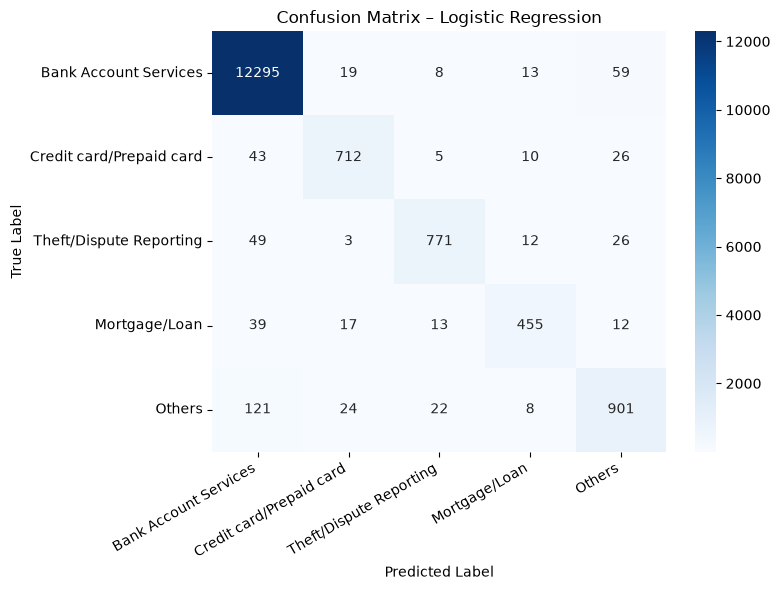

In [49]:
label_names = ['Bank Account Services', 'Credit card/Prepaid card',
               'Theft/Dispute Reporting', 'Mortgage/Loan', 'Others']

# ── Model 1: Logistic Regression ─────────────────────────────────────────────
print('=' * 60)
print('Model 1: Logistic Regression')
print('=' * 60)
lr = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, lr_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, lr_pred, target_names=label_names))

# ── Model 2: Decision Tree ────────────────────────────────────────────────────
print('=' * 60)
print('Model 2: Decision Tree')
print('=' * 60)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, dt_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, dt_pred, target_names=label_names))

# ── Model 3: Random Forest ────────────────────────────────────────────────────
print('=' * 60)
print('Model 3: Random Forest')
print('=' * 60)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, rf_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=label_names))

# ── Accuracy Comparison ────────────────────────────────────────────────────────
print('\n' + '=' * 60)
print('Model Accuracy Comparison')
print('=' * 60)
results = {
    'Logistic Regression': accuracy_score(y_test, lr_pred),
    'Decision Tree':       accuracy_score(y_test, dt_pred),
    'Random Forest':       accuracy_score(y_test, rf_pred),
}
for model_name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f'  {model_name:<25}: {acc:.4f}')

best_model_name = max(results, key=results.get)
print(f'\nBest model: {best_model_name} (accuracy = {results[best_model_name]:.4f})')

# Store best model for inference
best_model = lr if best_model_name == 'Logistic Regression' else (
             rf if best_model_name == 'Random Forest' else dt)

# ── Confusion Matrix for best model ──────────────────────────────────────────
best_pred = lr_pred if best_model_name == 'Logistic Regression' else (
            rf_pred if best_model_name == 'Random Forest' else dt_pred)

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title(f'Confusion Matrix – {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


In [50]:
# ── Model Inference: predict category for a new, unseen complaint ─────────────

# Reverse label map for readable output
reverse_label = {
    0: 'Bank Account Services',
    1: 'Credit card or prepaid card',
    2: 'Theft/Dispute Reporting',
    3: 'Mortgage/Loan',
    4: 'Others'
}

def predict_complaint(text):
    """Given raw complaint text, return the predicted business category."""
    # Reuse the CountVectorizer and TfidfTransformer fitted on training data
    vec = cv.transform([text])
    tfidf_vec = tfidf_transformer.transform(vec)
    prediction = best_model.predict(tfidf_vec)[0]
    return reverse_label.get(prediction, 'Unknown')


# --- Test complaint 1: Banking issue ---
complaint_1 = (
    "I have been trying to get my bank to reverse an unauthorised charge on my checking account. "
    "The bank refused to reimburse the funds and keep telling me to call back later."
)
print('Complaint 1:')
print(complaint_1)
print(f'Predicted Category: {predict_complaint(complaint_1)}')

print()

# --- Test complaint 2: Credit card issue ---
complaint_2 = (
    "I noticed a fraudulent charge on my credit card statement that I did not make. "
    "I contacted the credit card company but they have not resolved the dispute yet."
)
print('Complaint 2:')
print(complaint_2)
print(f'Predicted Category: {predict_complaint(complaint_2)}')

print()

# --- Test complaint 3: Mortgage issue ---
complaint_3 = (
    "I applied for a mortgage loan modification because I was facing financial hardship. "
    "The lender denied my application without providing a valid reason."
)
print('Complaint 3:')
print(complaint_3)
print(f'Predicted Category: {predict_complaint(complaint_3)}')

Complaint 1:
I have been trying to get my bank to reverse an unauthorised charge on my checking account. The bank refused to reimburse the funds and keep telling me to call back later.
Predicted Category: Bank Account Services

Complaint 2:
I noticed a fraudulent charge on my credit card statement that I did not make. I contacted the credit card company but they have not resolved the dispute yet.
Predicted Category: Credit card or prepaid card

Complaint 3:
I applied for a mortgage loan modification because I was facing financial hardship. The lender denied my application without providing a valid reason.
Predicted Category: Theft/Dispute Reporting
